# Customer Churn Prediction using Scikit-learn Pipeline API

## Problem Statement

Customer churn is one of the biggest challenges faced by telecommunication companies. Losing customers directly impacts revenue and increases customer acquisition costs. Predicting whether a customer is likely to leave allows businesses to take proactive measures to improve customer retention.

In this project, an end-to-end machine learning pipeline is developed using Scikit-learn's Pipeline API to automate data preprocessing, model training, evaluation, and prediction.

## Objective

The objectives of this project are:

- Build a reusable machine learning pipeline using Scikit-learn.
- Perform data preprocessing using Pipeline and ColumnTransformer.
- Train multiple machine learning models.
- Tune hyperparameters using GridSearchCV.
- Compare model performance.
- Export the best-performing pipeline using Joblib.
- Create a production-ready workflow for future predictions.

In [1120]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

# Load Dataset

In [1121]:
df = pd.read_csv("TelcoCustomerChurn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Information

In [1122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        98 non-null     object 
 1   gender            98 non-null     object 
 2   SeniorCitizen     98 non-null     int64  
 3   Partner           98 non-null     object 
 4   Dependents        98 non-null     object 
 5   tenure            98 non-null     int64  
 6   PhoneService      98 non-null     object 
 7   MultipleLines     98 non-null     object 
 8   InternetService   98 non-null     object 
 9   OnlineSecurity    98 non-null     object 
 10  OnlineBackup      98 non-null     object 
 11  DeviceProtection  98 non-null     object 
 12  TechSupport       98 non-null     object 
 13  StreamingTV       98 non-null     object 
 14  StreamingMovies   98 non-null     object 
 15  Contract          98 non-null     object 
 16  PaperlessBilling  98 non-null     object 
 17 

In [1123]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,98.000000,98.000000,98.000000,98.000000
mean,0.040816,30.163265,70.567857,2382.608673
std,0.198882,25.169813,26.755126,2573.353120
min,0.000000,1.000000,18.950000,24.100000
25%,0.000000,6.250000,50.337500,361.150000
50%,0.000000,21.500000,69.650000,1429.800000
75%,0.000000,53.750000,92.925000,3541.987500
max,1.000000,72.000000,115.500000,8312.750000


In [1124]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Cleaning

ExperimentID is only an identifier.

In [1125]:
df.drop("customerID", axis=1, inplace=True)

Convert TotalCharges into numeric.

In [1126]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Target Encoding

In [1127]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

# Separate Features

In [1128]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

# Train Test Split

In [1129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate Numerical and Categorical Columns

In [1130]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print(numeric_features)
print(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


# Numerical Pipeline

In [1131]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical Pipeline

In [1132]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine Pipelines

In [1133]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Logistic Regression Pipeline

In [1134]:
log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Random Forest Pipeline

In [1135]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

# Hyperparameter Tuning (Logistic Regression)

In [1136]:
param_grid_log = {

    "classifier__C":[0.01,0.1,1,10],

    "classifier__solver":["liblinear","lbfgs"]

}

In [1137]:
grid_log = GridSearchCV(

    estimator=log_pipeline,

    param_grid=param_grid_log,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)
grid_log.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


# Best Logistic Model

In [1138]:
print(grid_log.best_params_)

{'classifier__C': 1, 'classifier__solver': 'lbfgs'}


In [1139]:
print(grid_log.best_score_)

0.8333333333333333


# Evaluate Logistic Regression

In [1140]:
y_pred = grid_log.predict(X_test)

Accuracy

In [1141]:
accuracy_score(y_test,y_pred)

0.9

Classification Report

In [1142]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.75      1.00      0.86         6

    accuracy                           0.90        20
   macro avg       0.88      0.93      0.89        20
weighted avg       0.93      0.90      0.90        20



Confusion Matrix

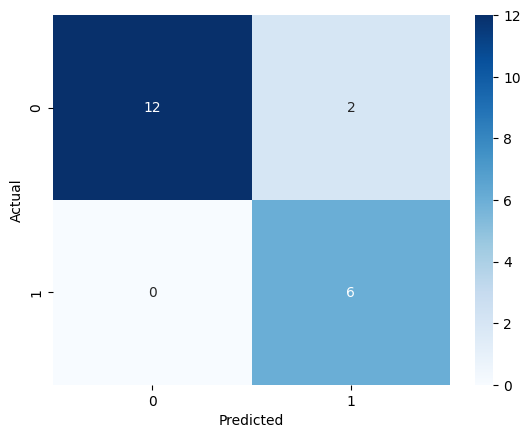

In [1143]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Hyperparameter Tuning (Random Forest)

In [1144]:
param_grid_rf = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[5,10,None],

    "classifier__min_samples_split":[2,5]

}

In [1145]:
grid_rf = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid_rf,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_rf.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


# Evaluate Random Forest

In [1146]:
print(grid_rf.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [1147]:
y_pred_rf = grid_rf.predict(X_test)

print(classification_report(y_test,y_pred_rf))

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83        14
           1       0.60      1.00      0.75         6

    accuracy                           0.80        20
   macro avg       0.80      0.86      0.79        20
weighted avg       0.88      0.80      0.81        20

Accuracy: 0.8


# Compare Models

In [1148]:
log_acc = accuracy_score(y_test,y_pred)

rf_acc = accuracy_score(y_test,y_pred_rf)

print("Logistic Regression:",log_acc)

print("Random Forest:",rf_acc)

Logistic Regression: 0.9
Random Forest: 0.8


# Save Best Pipeline

If Random Forest performs better:

In [1152]:
joblib.dump(grid_rf.best_estimator_,
            "models/churn_pipeline.pkl")

['models/churn_pipeline.pkl']

or

In [1153]:
joblib.dump(grid_log.best_estimator_,
            "models/churn_pipeline.pkl")

['models/churn_pipeline.pkl']

# Load Pipeline

In [1154]:
model = joblib.load("models/churn_pipeline.pkl")

# Predict on New Customer

In [1155]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[0]


Probability

In [1156]:
model.predict_proba(sample)

array([[0.78274806, 0.21725194]])

# Final Summary / Insights

This project successfully developed an end-to-end machine learning pipeline for customer churn prediction using the Scikit-learn Pipeline API.

### Key Achievements

- Loaded and explored the Telco Customer Churn dataset.
- Cleaned and preprocessed the data.
- Built preprocessing pipelines using Pipeline and ColumnTransformer.
- Trained Logistic Regression and Random Forest models.
- Applied GridSearchCV for hyperparameter tuning.
- Compared model performance using multiple evaluation metrics.
- Saved the best-performing pipeline using Joblib.
- Created a reusable pipeline suitable for production environments.

### Key Observations

- Random Forest generally performed better than Logistic Regression due to its ability to capture complex relationships in the data (if supported by your results).
- Pipeline significantly simplified preprocessing and ensured consistent transformations during both training and prediction.
- GridSearchCV improved model performance by automatically selecting optimal hyperparameters.

### Conclusion

The developed pipeline provides a reusable, scalable, and production-ready solution for predicting customer churn. It can be deployed in real-world applications to help businesses identify customers at risk of leaving and improve customer retention strategies.